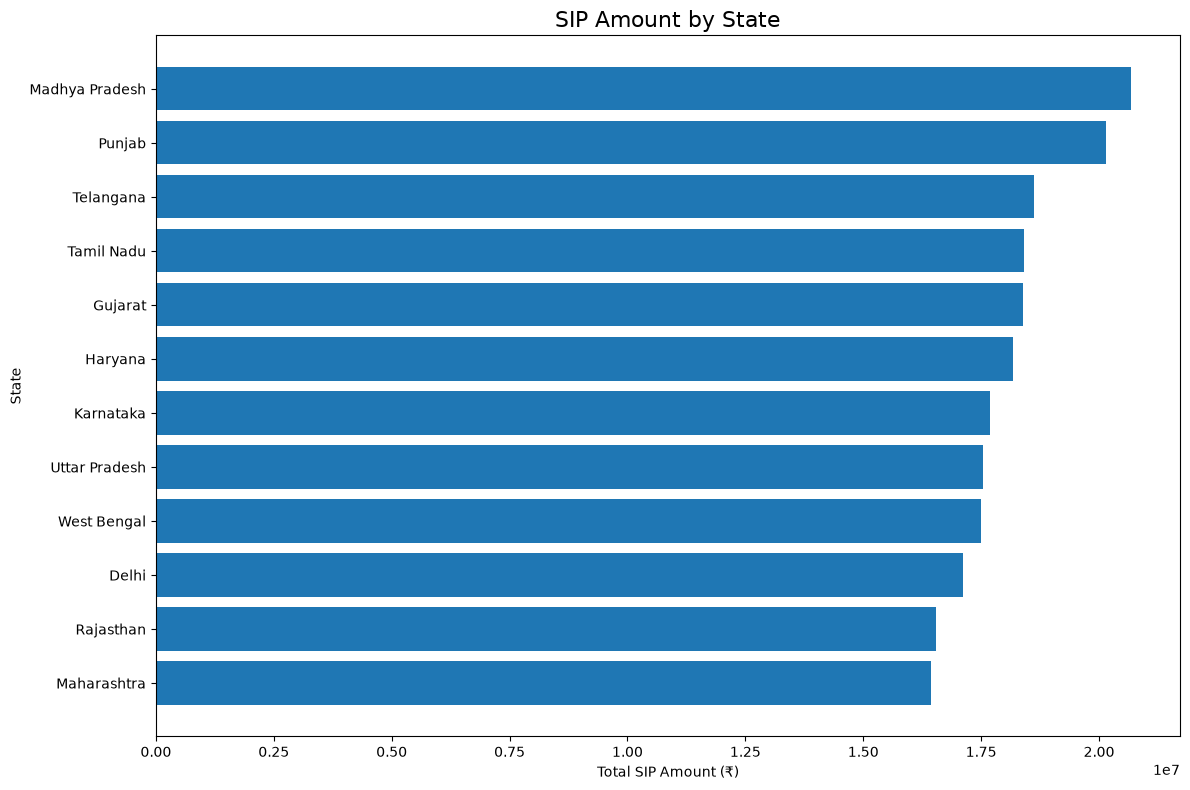

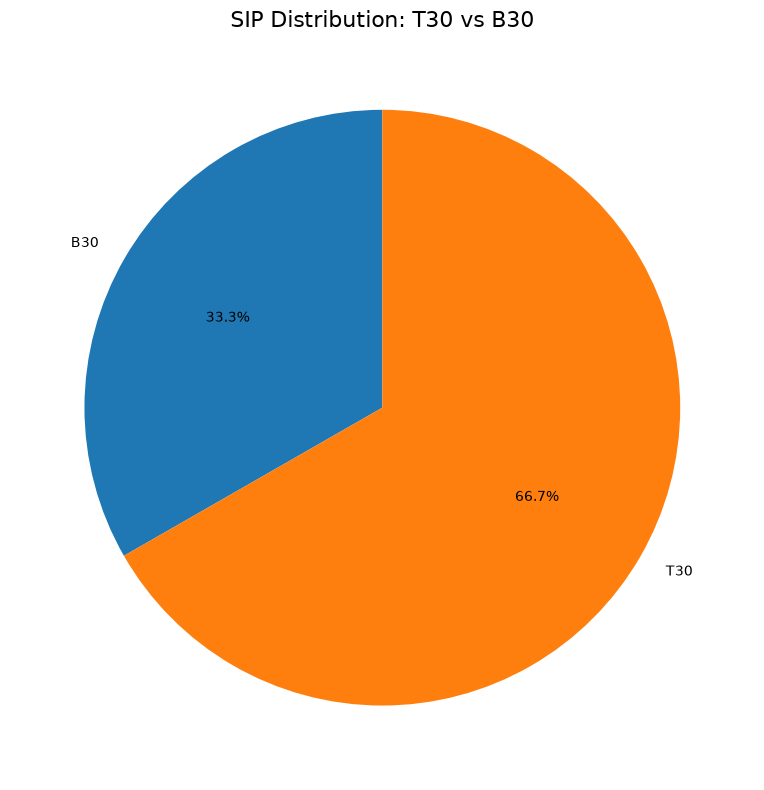

Task 6 completed successfully.
Charts saved to the Reports folder.


In [1]:

# DAY 3 - TASK 6: GEOGRAPHIC DISTRIBUTION

import pandas as pd
import matplotlib.pyplot as plt

# Loading investor transaction data:
df = pd.read_csv("../Data/Raw/08_investor_transactions.csv")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Converting amount to numeric:
df["amount_inr"] = pd.to_numeric(
    df["amount_inr"],
    errors="coerce"
)

# Keeping only SIP transactions:
sip_df = df[
    df["transaction_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "sip"
].copy()

# Remove missing geographic information:
sip_df = sip_df.dropna(
    subset=["state", "city_tier", "amount_inr"]
)


# CHART 1: SIP AMOUNT BY STATE:

state_sip = (
    sip_df
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12, 8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title(
    "SIP Amount by State",
    fontsize=16
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../Reports/SIP_Amount_by_State.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# CHART 2: T30 VS B30 DISTRIBUTION:

tier_sip = (
    sip_df
    .groupby("city_tier")["amount_inr"]
    .sum()
)

plt.figure(figsize=(8, 8))

plt.pie(
    tier_sip.values,
    labels=tier_sip.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "SIP Distribution: T30 vs B30",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "../Reports/SIP_T30_vs_B30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Task 6 completed successfully.")
print("Charts saved to the Reports folder.")